### Stage 4: ODE variant with regression-driven $b_1$ and $b_2$.

Replaces the calibrated scalar $b_1/b_2$ with daily predictions from the trained
RF or spline models. Runs the full 2017-2023 simulation and compares against:
  1. Observed $I_H$ data
  2. The weekly free-beta fit (tight benchmark the regression should match)
  3. The original scalar calibrated model (scalar $b_1/b_2$ per year)

Saves comparison figures and wMSE metrics.

In [1]:
import os
import sys
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
try:
    _SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # In Jupyter there is no __file__. Search downward for the 'regression'
    # folder that contains this notebook family (it has results/ and data/
    # siblings), so paths resolve regardless of the kernel launch directory.
    import pathlib
    _cwd = pathlib.Path(os.getcwd()).resolve()
    _reg = None
    for _p in _cwd.rglob("regression"):
        if not _p.is_dir():
            continue
        if (_p / "results").is_dir() and (_p / "data").is_dir():
            _reg = _p
            break
    if _reg is None:
        # Fallback: any regression dir under cwd
        for _p in _cwd.rglob("regression"):
            if _p.is_dir():
                _reg = _p
                break
    _SCRIPT_DIR = str(_reg) if _reg is not None else str(_cwd)
_PROJECT_ROOT = os.path.abspath(os.path.join(_SCRIPT_DIR, "..", "..", ".."))
_DATA_DIR = os.path.join(_PROJECT_ROOT, "data_files", "data")
_DETER_DIR = os.path.join(_DATA_DIR, "deter_notification_data")
_LMFIT_DIR = os.path.join(_SCRIPT_DIR, "..", "lmfit_optimization")
_RESULTS_DIR = os.path.join(_SCRIPT_DIR, "results")
os.makedirs(_RESULTS_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# Constants (matches lmfit_optimization_shared.py)
# ---------------------------------------------------------------------------
T_PRIME = 16.0
D1 = 24.8
B_E = 200
p_ME, p_ML, p_MP = 0.9, 0.25, 0.75
tau_E, tau_P = 1, 1
c1, c2 = 0.00554, -0.06737
A, B_c, C_c = -0.03, 1.31, -4.4
DD = 105
Tmin = 14.5
R_L = 32.67
M_min = 50000
SMOOTH_WINDOW = 14
optimal_temp_plasm = 23.5
critical_max_temp_plasm = 29.8
optimal_temp_anop = 25
critical_max_temp_anop = 34
critical_min_temp_anop = 16

YEARS = list(range(2017, 2024))

In [2]:
# ---------------------------------------------------------------------------
# Helper functions (from lmfit_optimization_shared.py)
# ---------------------------------------------------------------------------

def tau_L(Temp):
    denom = c1 * Temp + c2
    return 1.0 / denom if denom > 0 else 100.0

def tau_M(Temp):
    diff = Temp - Tmin
    return DD / diff if diff > 0 else 1000.0

def a_rate(Temp):
    return max(0.0, (Temp - T_PRIME) / D1)

def b_rate(Rain, Temp):
    tau_L_curr = tau_L(Temp)
    if tau_L_curr <= 0:
        return 0.0
    p_ER = (4 * p_ME / R_L**2) * Rain * (R_L - Rain) if 0 <= Rain <= R_L else 0.0
    p_LR = (4 * p_ML / R_L**2) * Rain * (R_L - Rain) if 0 <= Rain <= R_L else 0.0
    p_LT = np.exp(-(c1 * Temp + c2))
    p_PR = (4 * p_MP / R_L**2) * Rain * (R_L - Rain) if 0 <= Rain <= R_L else 0.0
    numer = B_E * p_ER * p_LR * p_LT * p_PR
    denom = tau_E + tau_L_curr + tau_P
    return numer / denom if denom > 0 else 0.0

def b3_briere_unscaled_plasm(Temp):
    return Temp * (Temp - Tmin) * (critical_max_temp_plasm - Temp) ** (1 / 2)


unscaled_peak_value_plasm = b3_briere_unscaled_plasm(optimal_temp_plasm)
desired_peak_rate_plasm = 1.0 / tau_M(optimal_temp_plasm)
eta_plasm = desired_peak_rate_plasm / unscaled_peak_value_plasm

def b3_briere_scaled_plasm(Temp):
    if Temp <= Tmin or Temp >= critical_max_temp_plasm:
        return 0.0
    return eta_plasm * Temp * (Temp - Tmin) * ((critical_max_temp_plasm - Temp) ** (1 / 2))

def temp_factor_briere_normalized_anop(Temp):
    if Temp <= critical_min_temp_anop or Temp >= critical_max_temp_anop:
        return 0.0
    raw = Temp * (Temp - critical_min_temp_anop) * ((critical_max_temp_anop - Temp) ** 0.5)
    opt_raw = (optimal_temp_anop * (optimal_temp_anop - critical_min_temp_anop)
               * ((critical_max_temp_anop - optimal_temp_anop) ** 0.5))
    return min(1.0, raw / opt_raw)

In [3]:
# ---------------------------------------------------------------------------
# Data loading
# ---------------------------------------------------------------------------

def load_climate_data():
    path = os.path.join(_DATA_DIR, "climate_api_data_2016_2024.csv")
    df = pd.read_csv(path, parse_dates=["date"])
    return df[(df["date"] >= "2017-01-01") & (df["date"] <= "2023-12-31")].reset_index(drop=True)

In [4]:
def load_cases_data():
    path = os.path.join(_DATA_DIR, "sivep_notification_data",
                         "treated_malaria_notification_data",
                         "cumulative_manaus_cases_2016_2023.csv")
    df = pd.read_csv(path, parse_dates=["date"])
    df = df[(df["date"] >= "2017-01-01") & (df["date"] <= "2023-12-31")].reset_index(drop=True)
    cols = ["active_total", "active_symptomatic", "active_asymptomatic",
            "new_cases", "cumulative_cases", "active_per_new_case"]
    df[cols] = df[cols] * (41.54 / 100)
    return df

In [5]:
def load_population():
    path = os.path.join(_DATA_DIR, "ibge_manaus_rural_population_data_2000_2025.csv")
    df = pd.read_csv(path)
    return dict(zip(df["year"], df["rural_population"]))

In [6]:
def load_deforestation_data():
    path = os.path.join(_DETER_DIR, "treated_deter_deforestation_data_2016_2024.csv")
    df = pd.read_csv(path, parse_dates=["date"])
    return df[(df["date"] >= "2017-01-01") & (df["date"] <= "2023-12-31")].copy()

In [7]:
def load_fire_data():
    path = os.path.join(_DATA_DIR, "inpe_fire_counts_data_2016_2024.csv")
    df = pd.read_csv(path, parse_dates=["date"])
    return df[(df["date"] >= "2017-01-01") & (df["date"] <= "2023-12-31")].copy()

In [8]:
# ---------------------------------------------------------------------------
# Daily feature computation
# ---------------------------------------------------------------------------

def compute_daily_b1b2_predictions(model_type="spline"):
    """Compute daily b1 and b2 predictions from trained model for 2017-2023."""
    climate = load_climate_data()
    defor = load_deforestation_data()
    fire = load_fire_data()

    # Merge daily data
    daily = climate[["date", "temp_med", "precip_med", "umid_min"]].copy()
    daily = daily.merge(defor[["date", "clear_cut_primary", "forest_degradation",
                                "burn_scar", "total_degradation"]], on="date", how="left")
    daily = daily.merge(fire[["date", "fire_counts"]], on="date", how="left")
    daily = daily.fillna(0)
    daily["year"] = daily["date"].dt.year
    daily["week_of_year"] = daily["date"].dt.isocalendar().week.astype(int)
    daily["day_of_year"] = daily["date"].dt.dayofyear - 1  # 0-based

    # 4-week rolling sums
    roll_cols = ["clear_cut_primary", "forest_degradation", "burn_scar",
                 "total_degradation", "fire_counts"]
    for col in roll_cols:
        daily[f"{col}_4wk"] = daily[col].rolling(window=28, min_periods=1).sum()

    # Sinusoidal week encoding
    daily["sin_week"] = np.sin(2 * np.pi * daily["week_of_year"] / 52)
    daily["cos_week"] = np.cos(2 * np.pi * daily["week_of_year"] / 52)

    # One-hot year
    for y in YEARS:
        daily[f"year_{y}"] = (daily["year"] == y).astype(int)

    # Core features (for spline)
    CORE_FEATURES = [
        "temp_mean", "precip_mean", "umid_min_mean",
        "defor_clearcut_4wk", "defor_degradation_4wk",
        "defor_burnscar_4wk", "fire_counts_4wk",
        "sin_week", "cos_week",
    ]
    # Rename to match training data column names
    daily_renamed = daily.rename(columns={
        "temp_med": "temp_mean",
        "precip_med": "precip_mean",
        "umid_min": "umid_min_mean",
        "clear_cut_primary_4wk": "defor_clearcut_4wk",
        "forest_degradation_4wk": "defor_degradation_4wk",
        "burn_scar_4wk": "defor_burnscar_4wk",
    })

    FULL_FEATURE_COLS = CORE_FEATURES + [f"year_{y}" for y in YEARS]

    if model_type == "spline":
        model_path = os.path.join(_RESULTS_DIR, "b1_eff_spline_model.pkl")
        with open(model_path, "rb") as f:
            spline_data = pickle.load(f)
        model = spline_data["model"]
        knots_dict = spline_data["knots"]

        X_core = daily_renamed[CORE_FEATURES].values
        X_spline = _build_spline_features_static(X_core, knots_dict)
        b1_pred = model.predict(X_spline)

        model_path2 = os.path.join(_RESULTS_DIR, "b2_eff_spline_model.pkl")
        with open(model_path2, "rb") as f:
            spline_data2 = pickle.load(f)
        model2 = spline_data2["model"]
        knots_dict2 = spline_data2["knots"]

        X_spline2 = _build_spline_features_static(X_core, knots_dict2)
        b2_pred = model2.predict(X_spline2)

    elif model_type == "rf":
        model_path = os.path.join(_RESULTS_DIR, "b1_eff_rf_model.pkl")
        with open(model_path, "rb") as f:
            b1_model = pickle.load(f)
        X_full = daily_renamed[FULL_FEATURE_COLS].values
        b1_pred = b1_model.predict(X_full)

        model_path2 = os.path.join(_RESULTS_DIR, "b2_eff_rf_model.pkl")
        with open(model_path2, "rb") as f:
            b2_model = pickle.load(f)
        b2_pred = b2_model.predict(X_full)
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    # Clip to plausible ranges
    b1_pred = np.clip(b1_pred, 0.001, 2.0)
    b2_pred = np.clip(b2_pred, 0.001, 1.0)

    daily["b1_pred"] = b1_pred
    daily["b2_pred"] = b2_pred

    # Compute a(T) for converting b1/b2 back to betas
    daily["a_T"] = [a_rate(t) for t in daily["temp_med"]]
    daily["beta_h_pred"] = daily["a_T"] * daily["b2_pred"]
    daily["beta_m_pred"] = daily["a_T"] * daily["b1_pred"]

    return daily

In [9]:
def _build_spline_features_static(X_core, knots_dict):
    """Build spline basis for prediction (static version)."""
    parts = []
    for col_idx in range(X_core.shape[1]):
        x = X_core[:, col_idx]
        feat = ["temp_mean", "precip_mean", "umid_min_mean",
                "defor_clearcut_4wk", "defor_degradation_4wk",
                "defor_burnscar_4wk", "fire_counts_4wk",
                "sin_week", "cos_week"][col_idx]
        knots = knots_dict.get(feat, [])
        if knots:
            K = len(knots)
            basis = np.zeros((len(x), K + 1))
            basis[:, 0] = x
            for j, t in enumerate(knots):
                basis[:, j + 1] = np.maximum(x - t, 0) ** 3
            parts.append(basis)
        else:
            parts.append(x.reshape(-1, 1))
    return np.hstack(parts)

In [10]:
# ---------------------------------------------------------------------------
# ODE simulation
# ---------------------------------------------------------------------------

def simulate_year_regression(year, state0, p, daily_b1b2, pop_by_year,
                              return_diagnostics=False):
    """Simulate one year with regression-driven b1/b2."""
    N = round(pop_by_year[year])
    H0v, kv, phiv = p["H0"], p["k"], p["phi"]
    tau_Hv, gammav, omegav = p["tau_H"], p["gamma"], p["omega"]
    M_prime_v = p["M_prime"]

    start = f"{year}-01-01"
    end = f"{year}-12-31"
    clim = load_climate_data()
    clim = clim[(clim["date"] >= start) & (clim["date"] <= end)].reset_index(drop=True)
    clim["temp_med_smooth"] = clim["temp_med"].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
    clim["precip_med_smooth"] = clim["precip_med"].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
    clim["umid_min_smooth"] = clim["umid_min"].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()

    # Get regression predictions for this year
    year_pred = daily_b1b2[daily_b1b2["year"] == year].reset_index(drop=True)
    b1_daily = year_pred["b1_pred"].values
    b2_daily = year_pred["b2_pred"].values

    def custom_p_T(Temp, Humid):
        denominator = A * Temp**2 + B_c * Temp + C_c
        p_T_temp = np.where(denominator <= 0, 0.0, np.exp(-1 / denominator))
        p_H = phiv + (1.0 - phiv) / (1.0 + np.exp(-kv * (Humid - H0v)))
        return p_T_temp * p_H

    def custom_mu(Temp, Humid):
        p_val = custom_p_T(Temp, Humid)
        return -np.log(p_val) if p_val > 0 else 1.0

    temp_med = clim["temp_med"].values
    precip_med = clim["precip_med"].values
    temp_smooth = clim["temp_med_smooth"].values
    precip_smooth = clim["precip_med_smooth"].values
    umid_smooth = clim["umid_min_smooth"].values
    n_days = len(clim)

    def ode_func(t, z):
        day_idx = int(t)
        day_idx = day_idx if day_idx < n_days else n_days - 1
        T_curr = temp_med[day_idx]
        R_curr = precip_med[day_idx]
        T_value = temp_smooth[day_idx]
        R_value = precip_smooth[day_idx]
        H_value = umid_smooth[day_idx]

        mu_curr = custom_mu(T_value, H_value)
        a_curr = a_rate(T_curr)
        tau_M_curr = tau_M(T_value)
        b3_m_curr = 1.0 / tau_M_curr if tau_M_curr > 0 else 0.0
        b3_h_curr = 1.0 / tau_Hv if tau_Hv > 0 else 0.0
        l_curr = np.exp(-mu_curr * tau_M_curr)
        b_curr = b_rate(R_value, T_value)
        b3_briere_curr = b3_briere_scaled_plasm(T_curr)

        S_H, E_H, I_H, R_H, S_M, E_M, I_M = z

        # Regression-driven FoI
        foi_h = a_curr * b2_daily[day_idx] * (I_M / N)
        foi_m = a_curr * b1_daily[day_idx] * (I_H / N)

        dShdt = -foi_h * S_H + omegav * R_H
        dEhdt = foi_h * S_H - b3_h_curr * E_H
        dIhdt = b3_h_curr * E_H - gammav * I_H
        dRhdt = gammav * I_H - omegav * R_H

        temp_factor = temp_factor_briere_normalized_anop(T_curr)
        habitat_creating_factor = 2 * R_curr / R_L
        habitat_flushing_factor = np.exp(1 - (2 * R_curr / R_L))
        rain_factor = habitat_creating_factor * habitat_flushing_factor

        K = max(M_prime_v * temp_factor * rain_factor, M_min)
        total_mosq = S_M + E_M + I_M
        density_factor = max(0, 1 - total_mosq / K) if K > 0 else 0.0
        mosquito_birth = b_curr * density_factor * K
        residual_birth_rate = mu_curr * M_min
        residual_recruitment = residual_birth_rate * max(0, 1 - total_mosq / M_min)
        mosquito_birth = mosquito_birth + residual_recruitment

        dSmdt = mosquito_birth - foi_m * S_M - mu_curr * S_M
        dEmdt = foi_m * S_M - (mu_curr + b3_briere_curr * l_curr) * E_M
        dImdt = b3_briere_curr * l_curr * E_M - mu_curr * I_M

        return [dShdt, dEhdt, dIhdt, dRhdt, dSmdt, dEmdt, dImdt]

    sol = solve_ivp(
        ode_func, [0, n_days], state0,
        t_eval=np.linspace(0, n_days, n_days * 10),
        method="LSODA",
    )
    if not sol.success:
        return None

    t_interp = np.linspace(0, sol.t[-1], n_days)
    IH_interp = interp1d(sol.t, sol.y[2])(t_interp)
    IM_interp = np.interp(t_interp, sol.t, sol.y[6])
    end_state = np.maximum(sol.y[:, -1].copy(), 0)

    if return_diagnostics:
        return clim["date"].values, IH_interp, end_state, {"im_min": float(np.min(sol.y[6]))}
    return clim["date"].values, IH_interp, end_state

In [11]:
# ---------------------------------------------------------------------------
# Calibrated model (scalar b1/b2)
# ---------------------------------------------------------------------------

def load_calibrated_params():
    """Load per-year calibrated parameters from lmfit_results.json."""
    path = os.path.join(_LMFIT_DIR, "lmfit_results.json")
    with open(path) as f:
        data = json.load(f)
    return data["per_year"]

In [12]:
def load_refined_params():
    """Load the refined parameters from lmfit_results.json (final params dict)."""
    calibrated = load_calibrated_params()
    result = {}
    for year_str, year_data in calibrated.items():
        result[int(year_str)] = year_data["params"]
    return result

In [13]:
def simulate_year_calibrated(year, state0, p, pop_by_year,
                              return_diagnostics=False):
    """Simulate one year with calibrated scalar b1/b2."""
    N = round(pop_by_year[year])
    H0v, kv, phiv = p["H0"], p["k"], p["phi"]
    tau_Hv, gammav, omegav = p["tau_H"], p["gamma"], p["omega"]
    M_prime_v = p["M_prime"]
    b1v, b2v = p["b1"], p["b2"]

    start = f"{year}-01-01"
    end = f"{year}-12-31"
    clim = load_climate_data()
    clim = clim[(clim["date"] >= start) & (clim["date"] <= end)].reset_index(drop=True)
    clim["temp_med_smooth"] = clim["temp_med"].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
    clim["precip_med_smooth"] = clim["precip_med"].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
    clim["umid_min_smooth"] = clim["umid_min"].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()

    def custom_p_T(Temp, Humid):
        denominator = A * Temp**2 + B_c * Temp + C_c
        p_T_temp = np.where(denominator <= 0, 0.0, np.exp(-1 / denominator))
        p_H = phiv + (1.0 - phiv) / (1.0 + np.exp(-kv * (Humid - H0v)))
        return p_T_temp * p_H

    def custom_mu(Temp, Humid):
        p_val = custom_p_T(Temp, Humid)
        return -np.log(p_val) if p_val > 0 else 1.0

    temp_med = clim["temp_med"].values
    precip_med = clim["precip_med"].values
    temp_smooth = clim["temp_med_smooth"].values
    precip_smooth = clim["precip_med_smooth"].values
    umid_smooth = clim["umid_min_smooth"].values
    n_days = len(clim)

    def ode_func(t, z):
        day_idx = int(t)
        day_idx = day_idx if day_idx < n_days else n_days - 1
        T_curr = temp_med[day_idx]
        R_curr = precip_med[day_idx]
        T_value = temp_smooth[day_idx]
        R_value = precip_smooth[day_idx]
        H_value = umid_smooth[day_idx]

        mu_curr = custom_mu(T_value, H_value)
        a_curr = a_rate(T_curr)
        tau_M_curr = tau_M(T_value)
        b3_m_curr = 1.0 / tau_M_curr if tau_M_curr > 0 else 0.0
        b3_h_curr = 1.0 / tau_Hv if tau_Hv > 0 else 0.0
        l_curr = np.exp(-mu_curr * tau_M_curr)
        b_curr = b_rate(R_value, T_value)
        b3_briere_curr = b3_briere_scaled_plasm(T_curr)

        S_H, E_H, I_H, R_H, S_M, E_M, I_M = z
        foi_h = a_curr * b2v * (I_M / N)
        foi_m = a_curr * b1v * (I_H / N)

        dShdt = -foi_h * S_H + omegav * R_H
        dEhdt = foi_h * S_H - b3_h_curr * E_H
        dIhdt = b3_h_curr * E_H - gammav * I_H
        dRhdt = gammav * I_H - omegav * R_H

        temp_factor = temp_factor_briere_normalized_anop(T_curr)
        habitat_creating_factor = 2 * R_curr / R_L
        habitat_flushing_factor = np.exp(1 - (2 * R_curr / R_L))
        rain_factor = habitat_creating_factor * habitat_flushing_factor

        K = max(M_prime_v * temp_factor * rain_factor, M_min)
        total_mosq = S_M + E_M + I_M
        density_factor = max(0, 1 - total_mosq / K) if K > 0 else 0.0
        mosquito_birth = b_curr * density_factor * K
        residual_birth_rate = mu_curr * M_min
        residual_recruitment = residual_birth_rate * max(0, 1 - total_mosq / M_min)
        mosquito_birth = mosquito_birth + residual_recruitment

        dSmdt = mosquito_birth - foi_m * S_M - mu_curr * S_M
        dEmdt = foi_m * S_M - (mu_curr + b3_briere_curr * l_curr) * E_M
        dImdt = b3_briere_curr * l_curr * E_M - mu_curr * I_M

        return [dShdt, dEhdt, dIhdt, dRhdt, dSmdt, dEmdt, dImdt]

    sol = solve_ivp(
        ode_func, [0, n_days], state0,
        t_eval=np.linspace(0, n_days, n_days * 10),
        method="LSODA",
    )
    if not sol.success:
        return None

    t_interp = np.linspace(0, sol.t[-1], n_days)
    IH_interp = interp1d(sol.t, sol.y[2])(t_interp)
    end_state = np.maximum(sol.y[:, -1].copy(), 0)

    if return_diagnostics:
        return clim["date"].values, IH_interp, end_state, {"im_min": float(np.min(sol.y[6]))}
    return clim["date"].values, IH_interp, end_state

In [14]:
# ---------------------------------------------------------------------------
# Weekly free-beta fit (tight benchmark)
# ---------------------------------------------------------------------------

def load_weekly_fit_betas(year):
    """Load the weekly free-beta fit for a year.

    Returns the fitted per-week beta arrays plus the initial conditions and
    fixed parameters that the weekly fit was optimized with. The IC and fixed
    params are essential: the beta arrays only reproduce the tight case-data
    fit when combined with the optimizer's own S_H0_frac/E_H0_frac/I_M0_ratio
    and H0/k/phi/tau_H/gamma/omega/M_prime (NOT the scalar calibration's).
    """
    path = os.path.join(_LMFIT_DIR, f"weekly_beta_results_{year}.json")
    with open(path) as f:
        data = json.load(f)
    bh = np.array(data["beta_h_weekly_fitted"])
    bm = np.array(data["beta_m_weekly_fitted"])
    ic = dict(data["refined_ic"])
    fp = dict(data["fixed_params"])
    return bh, bm, ic, fp

In [15]:
def _build_weekly_state(year, ic, pop_by_year, cases):
    """Build the weekly-fit initial state using its own IC fractions.

    Mirrors lmfit_optimization_shared.build_initial_state: I_H0 taken from the
    first observed active_total of the year, S_H0/E_H0 from fractions, R_H0 the
    residual, and mosquito compartments from I_M0_ratio with M0 = 10*N.
    """
    N = round(pop_by_year[year])
    obs_year = cases[cases["date"].dt.year == year].reset_index(drop=True)
    I_H0 = round(obs_year["active_total"].iloc[0])
    S_H0 = round(N * ic["S_H0_frac"])
    E_H0 = round(N * ic["E_H0_frac"])
    R_H0 = N - S_H0 - E_H0 - I_H0
    if S_H0 < 0 or E_H0 < 0 or R_H0 < 0:
        R_H0 = max(0, R_H0)
    M0 = 10 * N
    I_M0 = round(M0 * ic["I_M0_ratio"])
    E_M0 = round(I_M0 * 3)
    S_M0 = M0 - E_M0 - I_M0
    return np.array([S_H0, E_H0, I_H0, R_H0, S_M0, E_M0, I_M0], dtype=float)

In [16]:
def simulate_year_weekly_fit(year, state0, p, bh_weekly, bm_weekly, pop_by_year,
                             return_diagnostics=False):
    """Simulate one year using the weekly free-beta fit (piecewise-constant).

    This is the tight-tracking benchmark that the regression is trying to
    replace: beta_h/beta_m are free per week (from weekly_beta_results_*.json),
    so it reproduces the observed case curve far better than the scalar
    calibration. Mirrors the shared simulate_year(use_weekly_beta=True) path.
    The caller must pass state0 and p built from the weekly-fit's own IC and
    fixed params (see load_weekly_fit_betas).
    """
    N = round(pop_by_year[year])
    H0v, kv, phiv = p["H0"], p["k"], p["phi"]
    tau_Hv, gammav, omegav = p["tau_H"], p["gamma"], p["omega"]
    M_prime_v = p["M_prime"]

    start = f"{year}-01-01"
    end = f"{year}-12-31"
    clim = load_climate_data()
    clim = clim[(clim["date"] >= start) & (clim["date"] <= end)].reset_index(drop=True)
    clim["temp_med_smooth"] = clim["temp_med"].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
    clim["precip_med_smooth"] = clim["precip_med"].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
    clim["umid_min_smooth"] = clim["umid_min"].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()

    def custom_p_T(Temp, Humid):
        denominator = A * Temp**2 + B_c * Temp + C_c
        p_T_temp = np.where(denominator <= 0, 0.0, np.exp(-1 / denominator))
        p_H = phiv + (1.0 - phiv) / (1.0 + np.exp(-kv * (Humid - H0v)))
        return p_T_temp * p_H

    def custom_mu(Temp, Humid):
        p_val = custom_p_T(Temp, Humid)
        return -np.log(p_val) if p_val > 0 else 1.0

    temp_med = clim["temp_med"].values
    precip_med = clim["precip_med"].values
    temp_smooth = clim["temp_med_smooth"].values
    precip_smooth = clim["precip_med_smooth"].values
    umid_smooth = clim["umid_min_smooth"].values
    n_days = len(clim)

    def ode_func(t, z):
        day_idx = int(t)
        day_idx = day_idx if day_idx < n_days else n_days - 1
        T_curr = temp_med[day_idx]
        R_curr = precip_med[day_idx]
        T_value = temp_smooth[day_idx]
        R_value = precip_smooth[day_idx]
        H_value = umid_smooth[day_idx]

        mu_curr = custom_mu(T_value, H_value)
        a_curr = a_rate(T_curr)
        tau_M_curr = tau_M(T_value)
        b3_m_curr = 1.0 / tau_M_curr if tau_M_curr > 0 else 0.0
        b3_h_curr = 1.0 / tau_Hv if tau_Hv > 0 else 0.0
        l_curr = np.exp(-mu_curr * tau_M_curr)
        b_curr = b_rate(R_value, T_value)
        b3_briere_curr = b3_briere_scaled_plasm(T_curr)

        S_H, E_H, I_H, R_H, S_M, E_M, I_M = z

        week_idx = min(int(day_idx // 7), len(bh_weekly) - 1)
        foi_h = bh_weekly[week_idx] * (I_M / N)
        foi_m = bm_weekly[week_idx] * (I_H / N)

        dShdt = -foi_h * S_H + omegav * R_H
        dEhdt = foi_h * S_H - b3_h_curr * E_H
        dIhdt = b3_h_curr * E_H - gammav * I_H
        dRhdt = gammav * I_H - omegav * R_H

        temp_factor = temp_factor_briere_normalized_anop(T_curr)
        habitat_creating_factor = 2 * R_curr / R_L
        habitat_flushing_factor = np.exp(1 - (2 * R_curr / R_L))
        rain_factor = habitat_creating_factor * habitat_flushing_factor

        K = max(M_prime_v * temp_factor * rain_factor, M_min)
        total_mosq = S_M + E_M + I_M
        density_factor = max(0, 1 - total_mosq / K) if K > 0 else 0.0
        mosquito_birth = b_curr * density_factor * K
        residual_birth_rate = mu_curr * M_min
        residual_recruitment = residual_birth_rate * max(0, 1 - total_mosq / M_min)
        mosquito_birth = mosquito_birth + residual_recruitment

        dSmdt = mosquito_birth - foi_m * S_M - mu_curr * S_M
        dEmdt = foi_m * S_M - (mu_curr + b3_briere_curr * l_curr) * E_M
        dImdt = b3_briere_curr * l_curr * E_M - mu_curr * I_M

        return [dShdt, dEhdt, dIhdt, dRhdt, dSmdt, dEmdt, dImdt]

    sol = solve_ivp(
        ode_func, [0, n_days], state0,
        t_eval=np.linspace(0, n_days, n_days * 10),
        method="LSODA",
    )
    if not sol.success:
        return None

    t_interp = np.linspace(0, sol.t[-1], n_days)
    IH_interp = interp1d(sol.t, sol.y[2])(t_interp)
    end_state = np.maximum(sol.y[:, -1].copy(), 0)

    if return_diagnostics:
        return clim["date"].values, IH_interp, end_state, {"im_min": float(np.min(sol.y[6]))}
    return clim["date"].values, IH_interp, end_state

In [17]:
# ---------------------------------------------------------------------------
# Weighted MSE
# ---------------------------------------------------------------------------

def compute_wMSE(dates, IH, obs_df, decay_rate=0.0015, initial_weight=5.0):
    """Compute weighted MSE between model IH and observed data."""
    model_interp = interp1d(
        pd.to_datetime(dates).astype(np.int64), IH,
        kind="linear", fill_value="extrapolate",
    )
    obs_dates_int = obs_df["date"].astype(np.int64).values
    model_at_obs = model_interp(obs_dates_int)
    observed = obs_df["active_total"].values

    start_dt = obs_df["date"].iloc[0]
    days_from_start = (obs_df["date"] - start_dt).dt.days.values.astype(float)
    weights = initial_weight * np.exp(-decay_rate * days_from_start)

    return float(np.sum(weights * (model_at_obs - observed) ** 2) / np.sum(weights))

Loading data...

Model: SPLINE



--- Year 2017 ---


  Regression wMSE: 1362534.39
  Weekly free-beta wMSE: 617.98


  Scalar calibrated wMSE: 81529.39

--- Year 2018 ---


  Regression wMSE: 4340330.74
  Weekly free-beta wMSE: 2407.48


...

  Scalar calibrated wMSE: 5011440.19

--- Year 2022 ---


  Regression wMSE: 7183575.09
  Weekly free-beta wMSE: 1758.70


  Scalar calibrated wMSE: 4239212.00

--- Year 2023 ---


  Regression wMSE: 10177445.77
  Weekly free-beta wMSE: 7715.34


  Scalar calibrated wMSE: 2245990.72

Summary — SPLINE
  2017: reg_wMSE=1362534.39, weekly_fit_wMSE=617.98, cal_wMSE=81529.39
  2018: reg_wMSE=4340330.74, weekly_fit_wMSE=2407.48, cal_wMSE=4192003.96
  2019: reg_wMSE=7465121.32, weekly_fit_wMSE=493.38, cal_wMSE=7647789.00
  2020: reg_wMSE=9277887.22, weekly_fit_wMSE=338.76, cal_wMSE=5322063.81
  2021: reg_wMSE=6934299.56, weekly_fit_wMSE=1465.13, cal_wMSE=5011440.19
  2022: reg_wMSE=7183575.09, weekly_fit_wMSE=1758.70, cal_wMSE=4239212.00
  2023: reg_wMSE=10177445.77, weekly_fit_wMSE=7715.34, cal_wMSE=2245990.72

  Mean regression wMSE: 6677313.44
  Mean weekly free-beta wMSE: 2113.82
  Mean scalar calibrated wMSE: 4105718.44


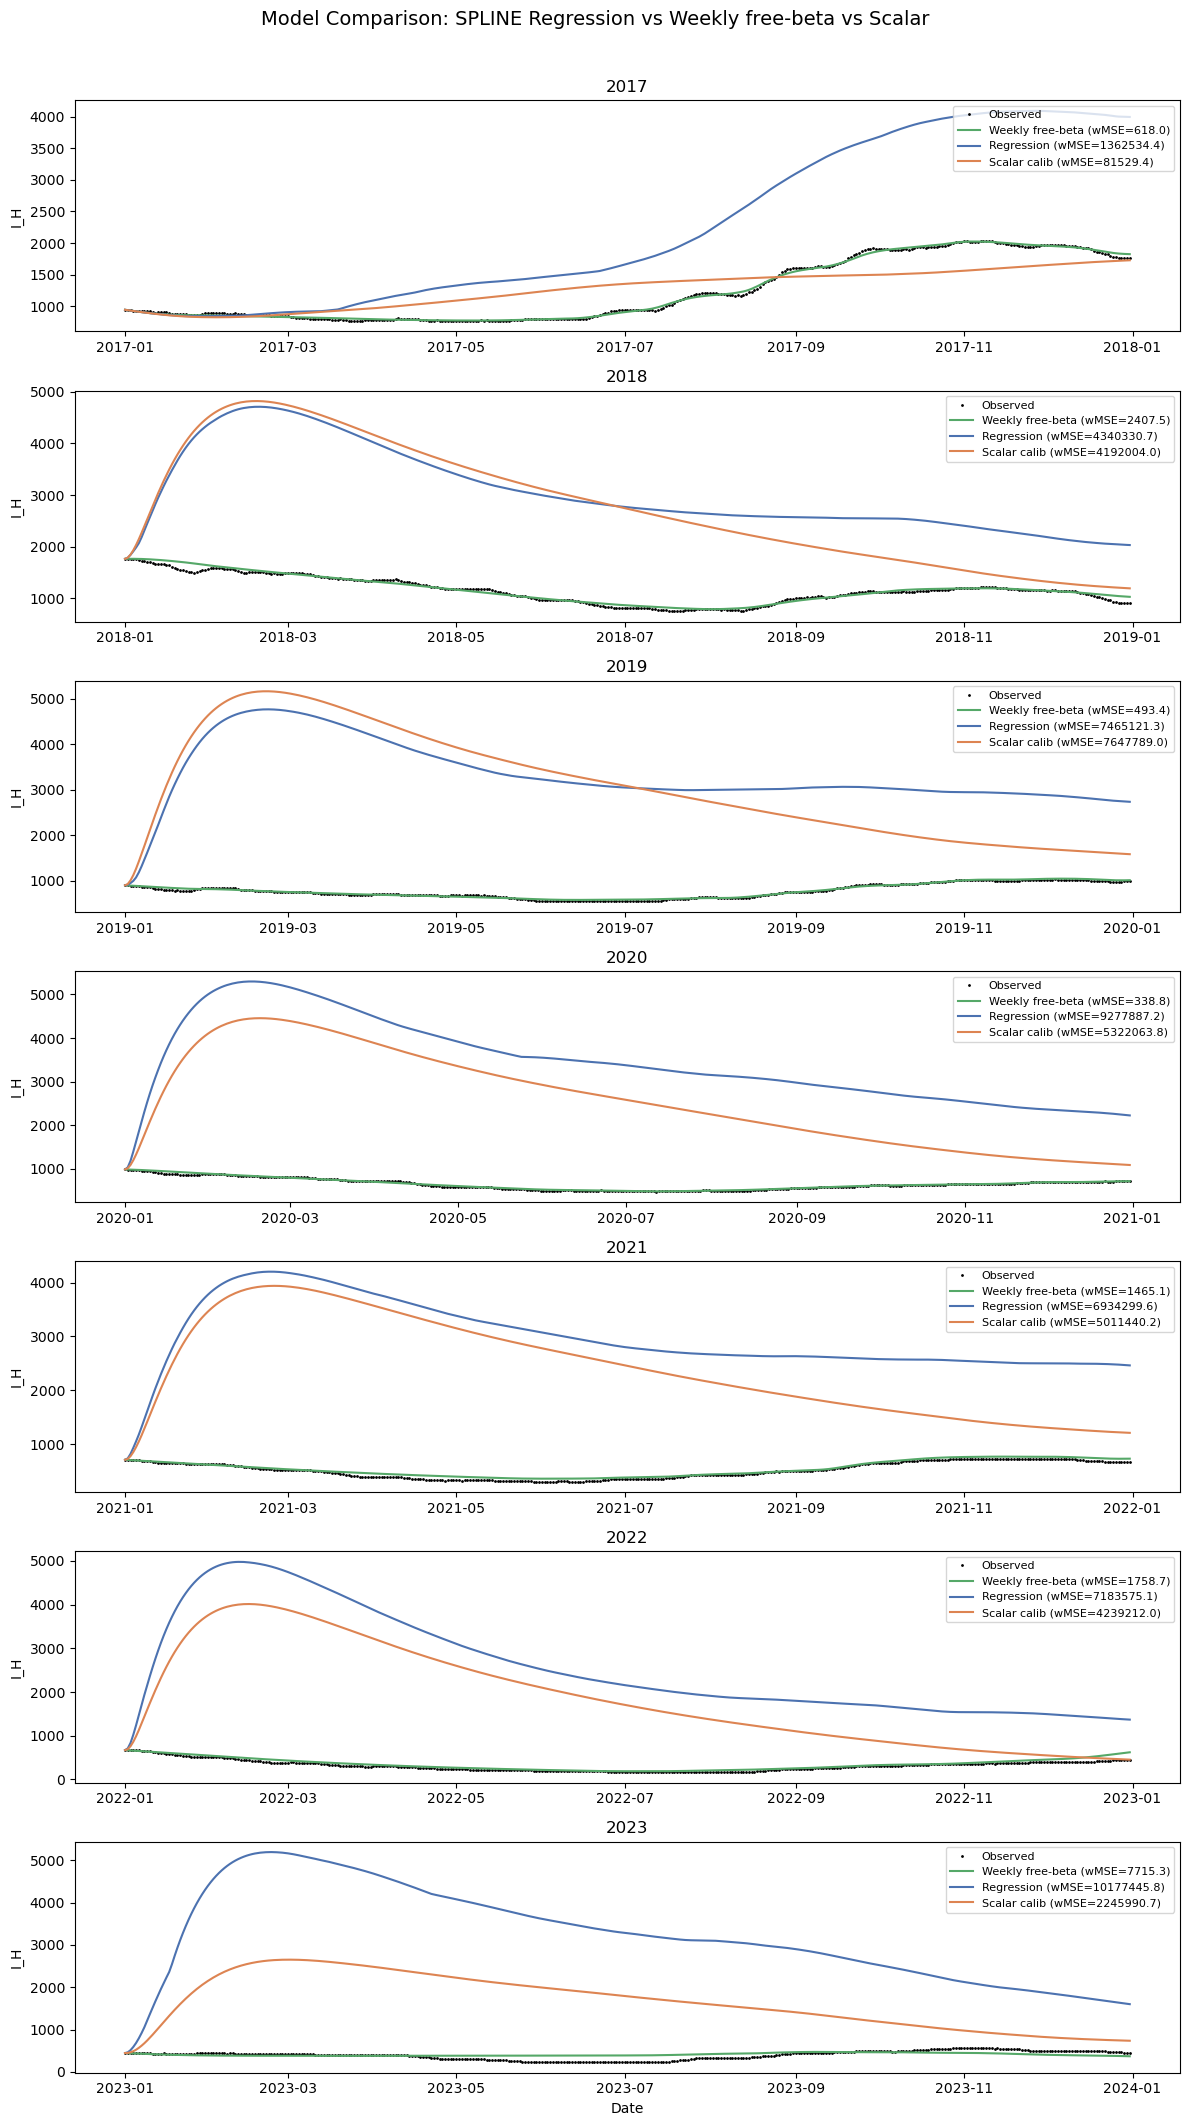


Model: RF



--- Year 2017 ---
  Regression wMSE: 103735.82


  Weekly free-beta wMSE: 617.98
  Scalar calibrated wMSE: 81529.39

--- Year 2018 ---


  Regression wMSE: 3806106.82
  Weekly free-beta wMSE: 2407.48


  Scalar calibrated wMSE: 4192003.96

--- Year 2019 ---
  Regression wMSE: 8300798.43


...

  Regression wMSE: 5973762.59
  Weekly free-beta wMSE: 1465.13


  Scalar calibrated wMSE: 5011440.19

--- Year 2022 ---


  Regression wMSE: 5945484.40
  Weekly free-beta wMSE: 1758.70


  Scalar calibrated wMSE: 4239212.00

--- Year 2023 ---
  Regression wMSE: 4740082.41


  Weekly free-beta wMSE: 7715.34
  Scalar calibrated wMSE: 2245990.72

Summary — RF
  2017: reg_wMSE=103735.82, weekly_fit_wMSE=617.98, cal_wMSE=81529.39
  2018: reg_wMSE=3806106.82, weekly_fit_wMSE=2407.48, cal_wMSE=4192003.96
  2019: reg_wMSE=8300798.43, weekly_fit_wMSE=493.38, cal_wMSE=7647789.00
  2020: reg_wMSE=7405753.38, weekly_fit_wMSE=338.76, cal_wMSE=5322063.81
  2021: reg_wMSE=5973762.59, weekly_fit_wMSE=1465.13, cal_wMSE=5011440.19
  2022: reg_wMSE=5945484.40, weekly_fit_wMSE=1758.70, cal_wMSE=4239212.00
  2023: reg_wMSE=4740082.41, weekly_fit_wMSE=7715.34, cal_wMSE=2245990.72

  Mean regression wMSE: 5182246.26
  Mean weekly free-beta wMSE: 2113.82
  Mean scalar calibrated wMSE: 4105718.44


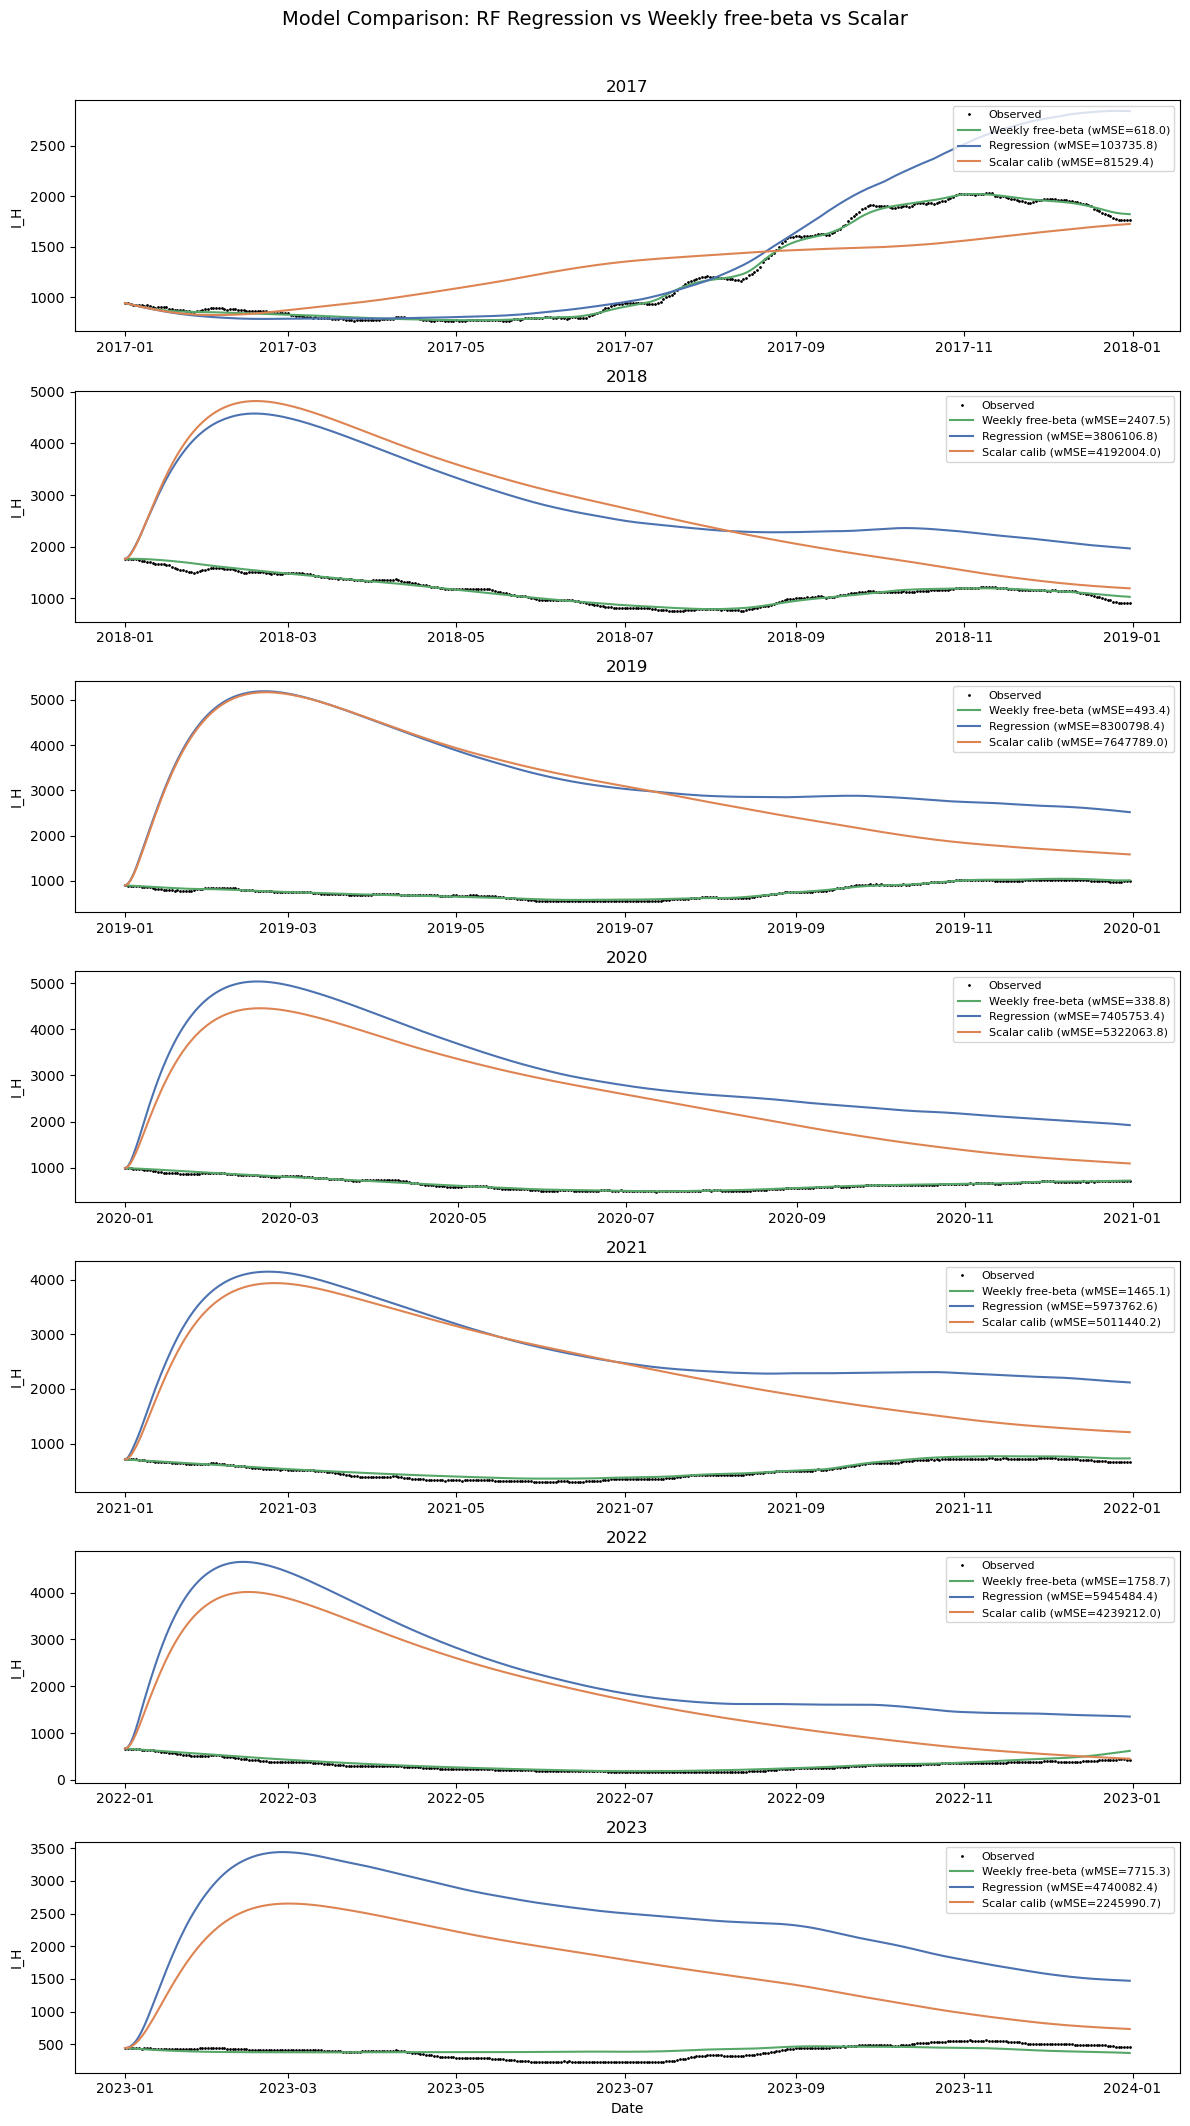


Done.


In [18]:
# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

def main():
    print("Loading data...")
    climate = load_climate_data()
    cases = load_cases_data()
    pop_by_year = load_population()

    # Compute regression predictions
    for model_type in ["spline", "rf"]:
        print(f"\n{'='*60}")
        print(f"Model: {model_type.upper()}")
        print(f"{'='*60}")

        daily_b1b2 = compute_daily_b1b2_predictions(model_type)

        # Load calibrated parameters
        calibrated_params = load_refined_params()

        all_results = {}
        wmses = {"regression": [], "calibrated": [], "weekly_fit": []}

        for year in YEARS:
            print(f"\n--- Year {year} ---")
            year_params = calibrated_params[year]

            # Initial conditions shared by all sims
            N = round(pop_by_year[year])
            obs_year = cases[cases["date"].dt.year == year].reset_index(drop=True)
            I_H0 = round(obs_year["active_total"].iloc[0])

            if "S_H0_frac" in year_params:
                S_H0 = round(N * year_params["S_H0_frac"])
                E_H0 = round(N * year_params["E_H0_frac"])
                M0 = round(year_params.get("M_prime", 10 * N))
                I_M0 = round(M0 * year_params.get("I_M0_ratio", 0.002))
                E_M0 = round(I_M0 * 3)
            else:
                S_H0 = round(N * 0.3)
                E_H0 = round(N * 0.001)
                M0 = 10 * N
                I_M0 = round(M0 * 0.002)
                E_M0 = round(I_M0 * 3)

            R_H0 = max(0, N - S_H0 - E_H0 - I_H0)
            S_M0 = max(0, M0 - E_M0 - I_M0)
            state0 = np.array([S_H0, E_H0, I_H0, R_H0, S_M0, E_M0, I_M0])

            p_reg = {
                "H0": year_params["H0"], "k": year_params["k"],
                "phi": year_params["phi"], "tau_H": year_params["tau_H"],
                "gamma": year_params["gamma"], "omega": year_params["omega"],
                "M_prime": year_params["M_prime"],
            }
            p_cal = year_params.copy()

            # --- Regression model ---
            res_reg = simulate_year_regression(year, state0, p_reg, daily_b1b2, pop_by_year,
                                                return_diagnostics=True)
            if res_reg is None:
                print(f"  Regression simulation failed for {year}")
                continue
            dates_reg, IH_reg, end_reg, diag_reg = res_reg
            wmse_reg = compute_wMSE(dates_reg, IH_reg, obs_year)
            print(f"  Regression wMSE: {wmse_reg:.2f}")

            # --- Weekly free-beta fit (tight benchmark) ---
            # Reconstruct the fit's own initial conditions and fixed params
            # (NOT the scalar calibration's) so the beta arrays reproduce the
            # tight case fit the optimizer achieved.
            bh_w, bm_w, wk_ic, wk_fp = load_weekly_fit_betas(year)
            state_wk = _build_weekly_state(year, wk_ic, pop_by_year, cases)
            res_fit = simulate_year_weekly_fit(year, state_wk, wk_fp, bh_w, bm_w,
                                                pop_by_year, return_diagnostics=True)
            if res_fit is not None:
                dates_fit, IH_fit, end_fit, diag_fit = res_fit
                wmse_fit = compute_wMSE(dates_fit, IH_fit, obs_year)
                print(f"  Weekly free-beta wMSE: {wmse_fit:.2f}")
                wmses["weekly_fit"].append(wmse_fit)
                IH_fit_plot = IH_fit
            else:
                print(f"  Weekly free-beta simulation failed for {year}")
                wmse_fit = None
                IH_fit_plot = None

            # --- Scalar calibrated model (original yearly climate calibration) ---
            res_cal = simulate_year_calibrated(year, state0, p_cal, pop_by_year,
                                                return_diagnostics=True)
            if res_cal is not None:
                dates_cal, IH_cal, end_cal, diag_cal = res_cal
                wmse_cal = compute_wMSE(dates_cal, IH_cal, obs_year)
                print(f"  Scalar calibrated wMSE: {wmse_cal:.2f}")
                wmses["calibrated"].append(wmse_cal)
            else:
                print(f"  Scalar calibrated simulation failed for {year}")
                wmse_cal = None

            wmses["regression"].append(wmse_reg)

            all_results[year] = {
                "dates": dates_reg,
                "IH_reg": IH_reg,
                "IH_fit": IH_fit_plot,
                "IH_cal": IH_cal if wmse_cal is not None else None,
                "obs": obs_year,
                "wmse_reg": wmse_reg,
                "wmse_fit": wmse_fit,
                "wmse_cal": wmse_cal,
            }

        # --- Summary ---
        print(f"\n{'='*60}")
        print(f"Summary — {model_type.upper()}")
        print(f"{'='*60}")
        for year in YEARS:
            if year in all_results:
                r = all_results[year]
                print(f"  {year}: reg_wMSE={r['wmse_reg']:.2f}", end="")
                if r["wmse_fit"] is not None:
                    print(f", weekly_fit_wMSE={r['wmse_fit']:.2f}", end="")
                if r["wmse_cal"] is not None:
                    print(f", cal_wMSE={r['wmse_cal']:.2f}", end="")
                print()

        mean_reg = np.mean(wmses["regression"])
        mean_fit = np.mean(wmses["weekly_fit"]) if wmses["weekly_fit"] else None
        mean_cal = np.mean(wmses["calibrated"]) if wmses["calibrated"] else None
        print(f"\n  Mean regression wMSE: {mean_reg:.2f}")
        if mean_fit is not None:
            print(f"  Mean weekly free-beta wMSE: {mean_fit:.2f}")
        if mean_cal is not None:
            print(f"  Mean scalar calibrated wMSE: {mean_cal:.2f}")

        # --- Plot ---
        n_years = len(all_results)
        fig, axes = plt.subplots(n_years, 1, figsize=(12, 3 * n_years), sharex=False)
        if n_years == 1:
            axes = [axes]

        for ax, year in zip(axes, YEARS):
            if year not in all_results:
                continue
            r = all_results[year]
            obs = r["obs"]
            ax.plot(obs["date"], obs["active_total"], "k.", markersize=2, label="Observed")
            if r["IH_fit"] is not None:
                ax.plot(r["dates"], r["IH_fit"], color="#55A868", linewidth=1.5,
                        label=f"Weekly free-beta (wMSE={r['wmse_fit']:.1f})")
            ax.plot(r["dates"], r["IH_reg"], color="#4C72B0", linewidth=1.5,
                    label=f"Regression (wMSE={r['wmse_reg']:.1f})")
            if r["IH_cal"] is not None:
                ax.plot(r["dates"], r["IH_cal"], color="#DD8452", linewidth=1.5,
                        label=f"Scalar calib (wMSE={r['wmse_cal']:.1f})")
            ax.set_ylabel("I_H")
            ax.set_title(f"{year}")
            ax.legend(fontsize=8, loc="upper right")

        axes[-1].set_xlabel("Date")
        plt.suptitle(f"Model Comparison: {model_type.upper()} Regression vs Weekly free-beta vs Scalar",
                      fontsize=14, y=1.01)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

        # Save wMSE summary
        summary = {
            "model_type": model_type,
            "mean_wMSE_regression": float(mean_reg),
            "mean_wMSE_weekly_fit": float(mean_fit) if mean_fit is not None else None,
            "mean_wMSE_calibrated": float(mean_cal) if mean_cal is not None else None,
            "per_year": {str(y): {
                "wMSE_reg": float(all_results[y]["wmse_reg"]),
                "wMSE_fit": float(all_results[y]["wmse_fit"]) if all_results[y]["wmse_fit"] is not None else None,
                "wMSE_cal": float(all_results[y]["wmse_cal"]) if all_results[y]["wmse_cal"] is not None else None,
            } for y in all_results},
        }
        summary_path = os.path.join(_RESULTS_DIR, f"ode_comparison_{model_type}.json")
        with open(summary_path, "w") as f:
            json.dump(summary, f, indent=2)

    print("\nDone.")


main()